# Analysis of fit structure in recurrent, input and output weights

## Hypothesis: Strongly multi-timescale task demands elicit tau aligned connectivity structure in heterogenous networks

In [1]:
import os

import glob
import matplotlib.pyplot as plt
import numpy as np
import torch

## Will look for each network construction, how different task timescale demands impact structure

### First, uniform RNNs of various taus

In [2]:
# getting all folders in rnn_results for uniform RNNs

uniform_dirs = glob.glob("../rnn_results/*uniform*")
print(uniform_dirs[0:2])

['../rnn_results/ktau0.1_delay0.1_uniform1.9_all_seed0', '../rnn_results/ktau0.1_delay0.1_uniform1.9_all_seed1']


In [3]:
# now separating by task and model details

ktaus = {f.split('ktau')[-1].split('_')[0] for f in uniform_dirs}
print(f'ktaus: {ktaus}')

delays = {f.split('delay')[-1].split('_')[0] for f in uniform_dirs}
print(f'delays: {delays}')

taus = {f.split('uniform')[-1].split('_')[0] for f in uniform_dirs}
print(f'taus: {taus}')

tau_apps = {f.split('_')[-2] for f in uniform_dirs}
print(f'tau_apps: {tau_apps}')


ktaus: {'1.9', '0.1'}
delays: {'1.9', '0.1', '0'}
taus: {'1', '1.9'}
tau_apps: {'all', 'decay'}


In [4]:
import itertools

separated_dirs = {}

for ktau, delay, tau, tau_app in itertools.product(ktaus, delays, taus, tau_apps):

    ktau_name = 'ktau' + ktau + '_'
    delay_name = 'delay' + delay + '_'
    tau_name = 'uniform' + tau + '_'

    separated_dirs[(ktau_name.split('_')[0], delay_name.split('_')[0], tau_name.split('_')[0], tau_app)] = [f for f in uniform_dirs if (ktau_name in f and tau_name in f and delay_name in f and tau_app in f)]

In [5]:
for key in separated_dirs:
    print(f'{key}: {len(separated_dirs[key])}')

('ktau1.9', 'delay1.9', 'uniform1', 'all'): 30
('ktau1.9', 'delay1.9', 'uniform1', 'decay'): 30
('ktau1.9', 'delay1.9', 'uniform1.9', 'all'): 30
('ktau1.9', 'delay1.9', 'uniform1.9', 'decay'): 30
('ktau1.9', 'delay0.1', 'uniform1', 'all'): 30
('ktau1.9', 'delay0.1', 'uniform1', 'decay'): 30
('ktau1.9', 'delay0.1', 'uniform1.9', 'all'): 30
('ktau1.9', 'delay0.1', 'uniform1.9', 'decay'): 30
('ktau1.9', 'delay0', 'uniform1', 'all'): 30
('ktau1.9', 'delay0', 'uniform1', 'decay'): 30
('ktau1.9', 'delay0', 'uniform1.9', 'all'): 30
('ktau1.9', 'delay0', 'uniform1.9', 'decay'): 30
('ktau0.1', 'delay1.9', 'uniform1', 'all'): 30
('ktau0.1', 'delay1.9', 'uniform1', 'decay'): 30
('ktau0.1', 'delay1.9', 'uniform1.9', 'all'): 30
('ktau0.1', 'delay1.9', 'uniform1.9', 'decay'): 30
('ktau0.1', 'delay0.1', 'uniform1', 'all'): 30
('ktau0.1', 'delay0.1', 'uniform1', 'decay'): 30
('ktau0.1', 'delay0.1', 'uniform1.9', 'all'): 30
('ktau0.1', 'delay0.1', 'uniform1.9', 'decay'): 30
('ktau0.1', 'delay0', 'unifo

Now that we have all vanilla dirs separated by condition, and values for each condition, we can move on to comparisons
First we will compare for $\tau = 0.1$ across ktaus and decays

In [14]:
tau = 'uniform1.9'
tau_app = 'all'
weights = {}
weights['rec'] = {}
weights['input'] = {}
weights['output'] = {}
weights['tau'] = {}

for ktau, delay in itertools.product(ktaus, delays):

    filepaths = separated_dirs[('ktau'+ktau, 'delay'+delay, tau, tau_app)]
    weights['rec'][(ktau, delay)] = []
    weights['input'][(ktau, delay)] = []
    weights['output'][(ktau, delay)] = []
    weights['tau'][(ktau, delay)] = []

    for filepath in filepaths:
        rnn = torch.load(filepath+'/best_model.pth')

        weights['rec'][(ktau, delay)].append(rnn['hh.weight'])
        weights['input'][(ktau, delay)].append(rnn['ih.weight'])
        weights['output'][(ktau, delay)].append(rnn['ho.weight'])
        weights['tau'][(ktau, delay)].append(rnn['taus'])

    weights['rec'][(ktau, delay)] = np.array(weights['rec'][(ktau, delay)])
    weights['input'][(ktau, delay)] = np.array(weights['input'][(ktau, delay)])
    weights['output'][(ktau, delay)] = np.array(weights['output'][(ktau, delay)])
    weights['tau'][(ktau, delay)] = np.array(weights['tau'][(ktau, delay)])

In [15]:
weights['rec'].keys()

dict_keys([('1.9', '1.9'), ('1.9', '0.1'), ('1.9', '0'), ('0.1', '1.9'), ('0.1', '0.1'), ('0.1', '0')])

In [ ]:
def correct_hh_for_tau(hh_list, taus_list):
    """
    Correct hh weights by multiplying each row by the corresponding τ.
    Returns a new list of corrected hh matrices.
    """
    corrected_hh = []
    for hh, taus in zip(hh_list, taus_list):
        hh_corr = hh.copy()
        for i in range(hh.shape[0]):
            hh_corr[i, :] *= taus[i]
        corrected_hh.append(hh_corr)
    return corrected_hh

def correct_ih_for_tau(ih_list, taus_list):
    """
    Correct ih weights by multiplying each row by the corresponding τ.
    Returns a new list of corrected ih matrices.
    """
    corrected_ih = []
    for ih, taus in zip(ih_list, taus_list):
        ih_corr = ih.copy()
        for i in range(ih.shape[0]):
            ih_corr[i, :] *= taus[i]
        corrected_ih.append(ih_corr)
    return corrected_ih

def frob_normalize(hh_list, ih_list=None, ho_list=None):
    """
    Normalize hh, ih, ho within each fit by the Frobenius norm of hh.
    Returns normalized copies; originals are unchanged.
    """
    hh_norm, ih_norm, ho_norm = [], [], []
    for f, hh in enumerate(hh_list):
        scale = np.linalg.norm(hh, 'fro')
        hh_norm.append(hh / scale)
        if ih_list is not None:
            ih_norm.append(ih_list[f] / scale)
        if ho_list is not None:
            ho_norm.append(ho_list[f] / scale)
    return (hh_norm,
            ih_norm if ih_list is not None else None,
            ho_norm if ho_list is not None else None)


def compute_tau_binned_weight_matrix(taus_list, hh_list, n_bins=10,
                                     magnitude=False, normalize=False):
    n_fits = len(taus_list)
    
    if normalize:
        hh_list, _, _ = frob_normalize(hh_list)


    all_taus = np.concatenate(taus_list)
    bin_edges = np.linspace(all_taus.min(), all_taus.max(), n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    fit_matrices = np.full((n_fits, n_bins, n_bins), np.nan)

    for f, (taus, hh) in enumerate(zip(taus_list, hh_list)):
        hh_proc = np.abs(hh) if magnitude else hh.copy()
        np.fill_diagonal(hh_proc, np.nan)
        bin_indices = np.clip(np.digitize(taus, bin_edges) - 1, 0, n_bins - 1)

        for i in range(n_bins):
            src_mask = np.where(bin_indices == i)[0]
            if len(src_mask) == 0:
                continue
            for j in range(n_bins):
                tgt_mask = np.where(bin_indices == j)[0]
                if len(tgt_mask) == 0:
                    continue
                fit_matrices[f, j, i] = np.nanmean(hh_proc[np.ix_(tgt_mask, src_mask)])

    mean_matrix = np.nanmean(fit_matrices, axis=0)
    var_matrix  = np.nanvar(fit_matrices, axis=0)
    return mean_matrix, var_matrix, bin_centers


def plot_heatmap(ax, fig, data, title, cmap, center_zero=False,
                 cbar_label='', tick_labels=None, n_bins=10):
    if center_zero:
        vabs = np.nanmax(np.abs(data))
        vmin, vmax = -vabs, vabs
    else:
        vmin, vmax = np.nanmin(data), np.nanmax(data)
    im = ax.imshow(data, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(n_bins))
    ax.set_yticks(range(n_bins))
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    ax.set_yticklabels(tick_labels)
    ax.set_xlabel('Source unit τ bin')
    ax.set_ylabel('Target unit τ bin')
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

In [ ]:
def plot_mean_magnitude_grid(weights, n_bins=20, normalize=True, cmap='viridis'):
    # sorted unique condition values (stored as strings)
    ktau_vals  = sorted({k for (k, d) in weights['rec'].keys()}, key=float)
    delay_vals = sorted({d for (k, d) in weights['rec'].keys()}, key=float)

    # first pass: compute all mean magnitude matrices + shared color scale
    mean_maps = {}
    global_vmax = 0.0
    last_bin_centers = None

    for k in ktau_vals:
        for d in delay_vals:
            taus_list = weights['tau'][(k, d)]
            hh_list   = weights['rec'][(k, d)]

            mean_mag, _, bin_centers = compute_tau_binned_weight_matrix(
                taus_list, hh_list, n_bins=n_bins, magnitude=True, normalize=normalize
            )
            mean_maps[(k, d)] = mean_mag
            last_bin_centers = bin_centers
            global_vmax = max(global_vmax, np.nanmax(mean_mag))

    tick_labels = [f"{c:.1f}" for c in last_bin_centers]
    tick_idx = np.arange(0, n_bins, max(1, n_bins // 5))

    # second pass: plot grid
    fig, axes = plt.subplots(
        len(ktau_vals), len(delay_vals),
        figsize=(4 * len(delay_vals), 3.8 * len(ktau_vals)),
        sharex=True, sharey=True
    )
    axes = np.atleast_2d(axes)

    im = None
    for i, k in enumerate(ktau_vals):
        for j, d in enumerate(delay_vals):
            ax = axes[i, j]
            data = mean_maps[(k, d)]
            im = ax.imshow(data, origin='lower', aspect='auto', cmap=cmap, vmin=0, vmax=global_vmax)
            ax.set_title(f"ktau={k}, delay={d}")

            ax.set_xticks(tick_idx)
            ax.set_yticks(tick_idx)
            ax.set_xticklabels([tick_labels[t] for t in tick_idx], rotation=45, ha='right')
            ax.set_yticklabels([tick_labels[t] for t in tick_idx])

            if i == len(ktau_vals) - 1:
                ax.set_xlabel("Source unit τ bin")
            if j == 0:
                ax.set_ylabel("Target unit τ bin")

    fig.subplots_adjust(right=0.90)  # leave room on the right
    cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Mean |weight|")

    norm_str = " (Frob. normalized)" if normalize else ""
    fig.suptitle(f"Mean recurrent weight magnitude by τ bin{norm_str}", y=1.02)
    plt.tight_layout()
    plt.show()

/var/folders/xv/mfd3j40n6tncjjmp5qypq8300000gt/T/ipykernel_72259/628516586.py:71: RuntimeWarning: Mean of empty slice
  fit_matrices[f, j, i] = np.nanmean(hh_proc[np.ix_(tgt_mask, src_mask)])
/var/folders/xv/mfd3j40n6tncjjmp5qypq8300000gt/T/ipykernel_72259/3167552275.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


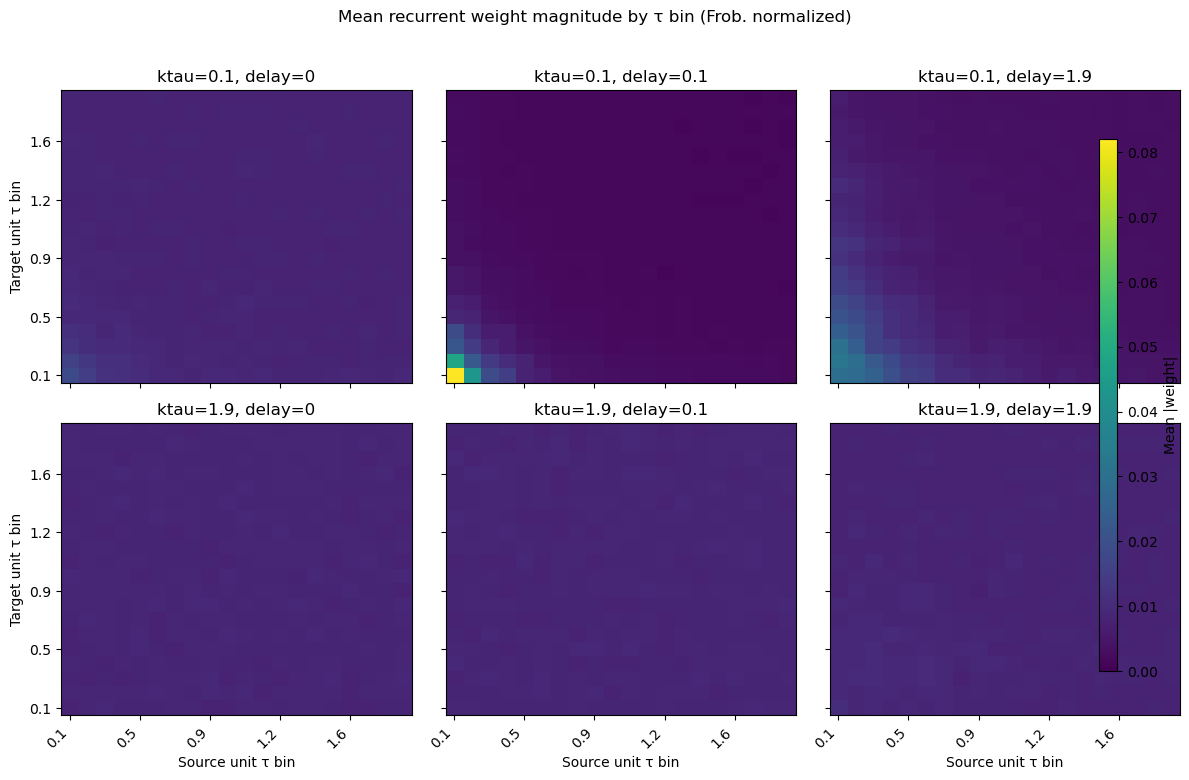

In [ ]:
plot_mean_magnitude_grid(weights, n_bins=20, normalize=True, cmap='viridis')

In [19]:
def compute_io_weights_by_tau(taus_list, weight_list, n_bins=10,
                               direction='input', magnitude=False):
    n_fits = len(taus_list)

    all_taus = np.concatenate(taus_list)
    bin_edges = np.linspace(all_taus.min(), all_taus.max(), n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    W0 = weight_list[0]
    n_dims = W0.shape[1] if direction == 'input' else W0.shape[0]
    fit_means = np.full((n_fits, n_bins, n_dims), np.nan)

    for f, (taus, W) in enumerate(zip(taus_list, weight_list)):
        W_proc = np.abs(W) if magnitude else W
        bin_indices = np.clip(np.digitize(taus, bin_edges) - 1, 0, n_bins - 1)

        for b in range(n_bins):
            unit_mask = bin_indices == b
            if not unit_mask.any():
                continue
            if direction == 'input':
                fit_means[f, b, :] = W_proc[unit_mask, :].mean(axis=0)
            else:
                fit_means[f, b, :] = W_proc[:, unit_mask].mean(axis=1)

    mean_by_bin = np.nanmean(fit_means, axis=0)
    sem_by_bin  = np.nanstd(fit_means, axis=0) / np.sqrt(n_fits)
    return mean_by_bin, sem_by_bin, bin_centers


def plot_dims(ax, bin_centers, mean, sem, colors, dim_label, title, ylabel):
    if mean.ndim > 1:
        for d in range(mean.shape[1]):
            ax.plot(bin_centers, mean[:, d], color=colors[d], lw=2,
                    marker='o', ms=4, label=f'{dim_label} {d+1}')
            ax.fill_between(bin_centers,
                            mean[:, d] - sem[:, d],
                            mean[:, d] + sem[:, d],
                            alpha=0.2, color=colors[d])
    else:
        ax.plot(bin_centers, mean, color=colors[0], lw=2,
                marker='o', ms=4, label=dim_label)
        ax.fill_between(bin_centers,
                        mean - sem,
                        mean + sem,
                        alpha=0.2, color=colors[0])
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Unit τ bin')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9, framealpha=0.5)


In [20]:
def plot_mean_input_grid(weights, n_bins=20, normalize=True):
    ktau_vals  = sorted({k for (k, _) in weights['rec'].keys()}, key=float)
    delay_vals = sorted({d for (_, d) in weights['rec'].keys()}, key=float)

    mean_maps = {}
    sem_maps = {}
    last_bin_centers = None
    global_yabs = 0.0

    for k in ktau_vals:
        for d in delay_vals:
            taus_list = weights['tau'][(k, d)]
            ih_list = weights['input'][(k, d)]

            if normalize:
                hh_list = weights['rec'][(k, d)]
                _, ih_norm, _ = frob_normalize(hh_list, ih_list=ih_list)
                ih_use = np.array(ih_norm)
            else:
                ih_use = ih_list

            mean_inp, sem_inp, bin_centers = compute_io_weights_by_tau(
                taus_list, ih_use, n_bins=n_bins, direction='input', magnitude=True
            )

            mean_maps[(k, d)] = mean_inp
            sem_maps[(k, d)] = sem_inp
            last_bin_centers = bin_centers
            global_yabs = max(global_yabs, np.nanmax(np.abs(mean_inp) + sem_inp))

    colors = plt.cm.tab10.colors
    tick_idx = np.arange(0, n_bins, max(1, n_bins // 5))
    x_ticks = last_bin_centers[tick_idx]

    fig, axes = plt.subplots(
        len(ktau_vals), len(delay_vals),
        figsize=(4 * len(delay_vals), 3.8 * len(ktau_vals)),
        sharex=True, sharey=True
    )
    axes = np.atleast_2d(axes)

    for i, k in enumerate(ktau_vals):
        for j, d in enumerate(delay_vals):
            ax = axes[i, j]
            mean_inp = mean_maps[(k, d)]
            sem_inp = sem_maps[(k, d)]

            n_dims = mean_inp.shape[1] if mean_inp.ndim > 1 else 1
            for dim in range(n_dims):
                y = mean_inp[:, dim] if n_dims > 1 else mean_inp.squeeze()
                yerr = sem_inp[:, dim] if n_dims > 1 else sem_inp.squeeze()
                ax.errorbar(
                    last_bin_centers, y, yerr=yerr,
                    color=colors[dim % len(colors)],
                    marker='o', ms=3, lw=1.5, capsize=2,
                    label=f'Input dim {dim+1}'
                )

            ax.axhline(0, color='k', lw=0.8, ls='--')
            ax.set_title(f"ktau={k}, delay={d}")
            ax.set_xlim(last_bin_centers[0], last_bin_centers[-1])
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([f"{x:.1f}" for x in x_ticks], rotation=45, ha='right')

            if i == len(ktau_vals) - 1:
                ax.set_xlabel("Unit τ bin")
            if j == 0:
                ax.set_ylabel("Mean input weight")
            if n_dims > 1:
                ax.legend(fontsize=8, framealpha=0.5)

    if global_yabs > 0:
        for ax_row in axes:
            for ax in np.atleast_1d(ax_row):
                ax.set_ylim(-1.05 * global_yabs, 1.05 * global_yabs)

    fig.suptitle(
        "Mean input weight by unit τ bin" + (" (Frob. normalized)" if normalize else ""),
        y=1.02
    )
    plt.tight_layout()
    plt.show()


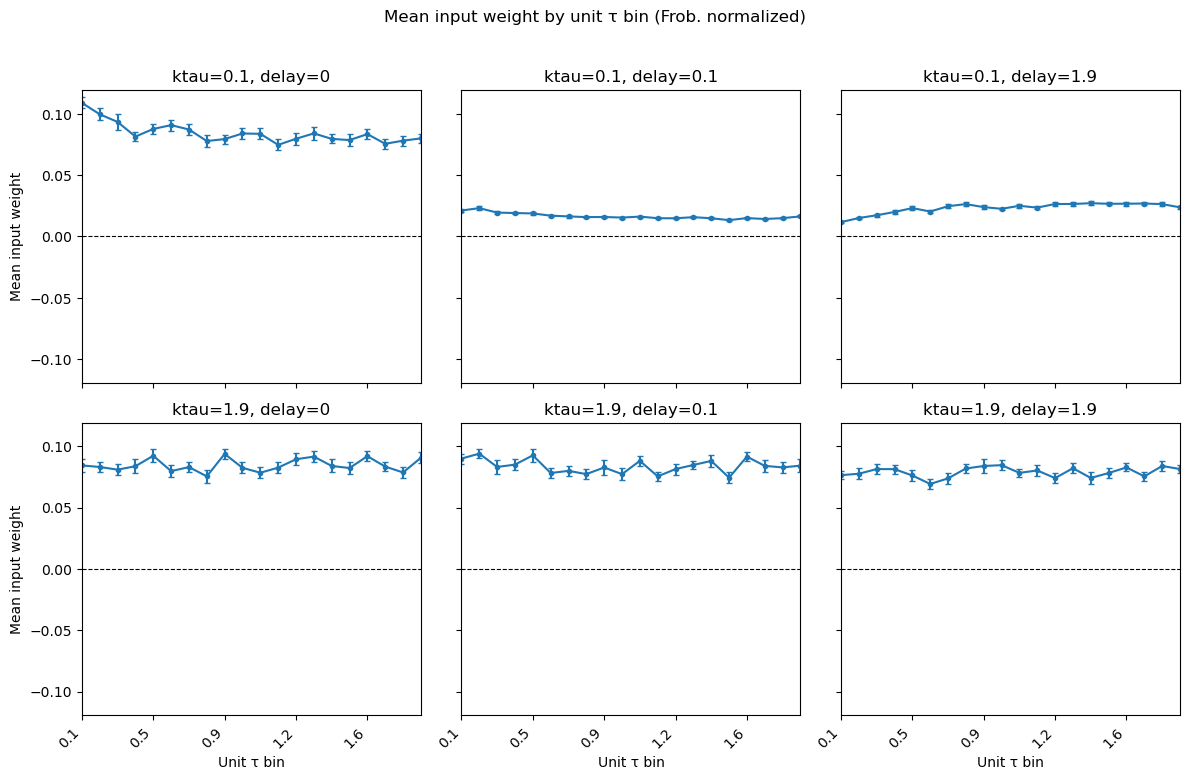

In [21]:
plot_mean_input_grid(weights, n_bins=20, normalize=True)